# 01 — TMDB + OMDb → Raw Dataset (movies_clean.csv)

This section collects movie data from TMDB and enriches it from OMDb.
Output: `data/raw/movies_clean.csv`

In [13]:
!pip -q install requests pandas tqdm python-dotenv

import requests
import pandas as pd
import time
from tqdm import tqdm
from pathlib import Path

## Load API Keys from `.env`

Your `.env` file must contain:

TMDB_API_KEY=...
OMDB_API_KEY=...

In [14]:
eda_only = False  # True = skip API collection + ETL sections


In [15]:
import sys
from pathlib import Path

# Add parent directory to path so we can import from src
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

from src.utils.env import TMDB_API_KEY, OMDB_API_KEY

TMDB_BASE = "https://api.themoviedb.org/3"
OMDB_BASE = "https://www.omdbapi.com/"

In [16]:
def tmdb_discover_movies(page=1, sort_by="popularity.desc", min_votes=200):
    url = f"{TMDB_BASE}/discover/movie"
    params = {
        "api_key": TMDB_API_KEY,
        "page": page,
        "sort_by": sort_by,
        "vote_count.gte": min_votes,
        "include_adult": "false",
        "include_video": "false",
        "language": "en-US"
    }
    return get_json(url, params=params)

In [17]:
def omdb_by_imdb_id(imdb_id):
    params = {"apikey": OMDB_API_KEY, "i": imdb_id, "plot": "short"}
    return get_json(OMDB_BASE, params=params)

def safe_float(x):
    try:
        return float(x)
    except:
        return None

def safe_int_from_votes(v):
    try:
        return int(str(v).replace(",", ""))
    except:
        return None

In [18]:
def get_json(url, params=None):
    """Helper function to make API requests"""
    try:
        response = requests.get(url, params=params, timeout=10)
        if response.status_code == 200:
            return response.json()
        return None
    except Exception as e:
        print(f"Error fetching {url}: {e}")
        return None

def tmdb_movie_details(movie_id):
    """Get detailed info for a specific movie from TMDB"""
    url = f"{TMDB_BASE}/movie/{movie_id}"
    params = {"api_key": TMDB_API_KEY, "language": "en-US"}
    return get_json(url, params=params)

def tmdb_movie_credits(movie_id):
    """Get credits (cast & crew) for a specific movie from TMDB"""
    url = f"{TMDB_BASE}/movie/{movie_id}/credits"
    params = {"api_key": TMDB_API_KEY}
    return get_json(url, params=params)

def extract_director_and_cast(credits, top_n_cast=5):
    """Extract director and top cast from credits"""
    director = None
    top_cast = None
    
    if not isinstance(credits, dict):
        return director, top_cast
    
    # Extract director
    crew = credits.get("crew", [])
    if crew:
        for person in crew:
            if person.get("job") == "Director":
                director = person.get("name")
                break
    
    # Extract top cast
    cast = credits.get("cast", [])
    if cast:
        cast_names = [person.get("name") for person in cast[:top_n_cast] if person.get("name")]
        top_cast = ", ".join(cast_names) if cast_names else None
    
    return director, top_cast

In [19]:
# Collect movies from TMDB (discover endpoint)
if not eda_only:
    all_results = []
    num_pages = 5  # Adjust this to collect more or fewer movies (20 movies per page)
    
    print(f"Collecting movies from TMDB (pages 1-{num_pages})...")
    for page in range(1, num_pages + 1):
        print(f"  Fetching page {page}...")
        response = tmdb_discover_movies(page=page, sort_by="popularity.desc", min_votes=200)
        
        if response and "results" in response:
            all_results.extend(response["results"])
            time.sleep(0.25)  # Rate limiting
        else:
            print(f"  Warning: No results for page {page}")
    
    # Create DataFrame
    tmdb_list_df = pd.DataFrame(all_results)
    
    # Rename columns to match expected names
    if "id" in tmdb_list_df.columns:
        tmdb_list_df = tmdb_list_df.rename(columns={
            "id": "tmdb_id",
            "vote_average": "tmdb_vote_average",
            "vote_count": "tmdb_vote_count"
        })
    
    print(f"Collected {len(tmdb_list_df)} movies from TMDB")
    print(f"Sample columns: {list(tmdb_list_df.columns[:5])}")
else:
    print("Skipping TMDB collection (eda_only=True)")

  Fetching page 1...
  Fetching page 2...
  Fetching page 3...
  Fetching page 4...
  Fetching page 5...
Collected 100 movies from TMDB
Sample columns: ['adult', 'backdrop_path', 'genre_ids', 'tmdb_id', 'original_language']


In [20]:
# Enrich movies with detailed info from TMDB and OMDb
if not eda_only:
    enriched = []

    for _, row in tqdm(tmdb_list_df.iterrows(), total=len(tmdb_list_df), desc="Enrich movies"):
        mid = int(row["tmdb_id"])
        details = tmdb_movie_details(mid)
        credits = tmdb_movie_credits(mid)

        imdb_id = details.get("imdb_id") if isinstance(details, dict) else None
        runtime = details.get("runtime") if isinstance(details, dict) else None

        genres = None
        if isinstance(details, dict):
            g = details.get("genres", []) or []
            genres = ", ".join([x.get("name") for x in g if x.get("name")])

        director, top_cast = extract_director_and_cast(credits, top_n_cast=5)

        imdb_rating = imdb_votes = metascore = None
        rated = awards = box_office = None
        omdb_genre = omdb_plot = None

        if imdb_id and isinstance(imdb_id, str) and imdb_id.startswith("tt"):
            om = omdb_by_imdb_id(imdb_id)
            if isinstance(om, dict) and om.get("Response") == "True":
                imdb_rating = safe_float(om.get("imdbRating"))
                imdb_votes = safe_int_from_votes(om.get("imdbVotes"))
                metascore = safe_int_from_votes(om.get("Metascore"))
                rated = om.get("Rated")
                awards = om.get("Awards")
                box_office = om.get("BoxOffice")
                omdb_genre = om.get("Genre")
                omdb_plot = om.get("Plot")
            
            # Rate limiting for OMDb API
            time.sleep(0.2)

        poster_url = None
        if row.get("poster_path"):
            poster_url = f"https://image.tmdb.org/t/p/w500{row['poster_path']}"

        enriched.append({
            "tmdb_id": mid,
            "imdb_id": imdb_id,
            "title": row.get("title"),
            "release_date": row.get("release_date"),
            "year": (str(row.get("release_date"))[:4] if row.get("release_date") else None),
            "runtime": runtime,
            "genres_tmdb": genres,
            "genres_omdb": omdb_genre,
            "overview_tmdb": row.get("overview"),
            "plot_omdb": omdb_plot,
            "director": director,
            "top_cast": top_cast,
            "tmdb_rating": row.get("tmdb_vote_average"),
            "tmdb_vote_count": row.get("tmdb_vote_count"),
            "popularity": row.get("popularity"),
            "imdb_rating": imdb_rating,
            "imdb_votes": imdb_votes,
            "metascore": metascore,
            "rated": rated,
            "awards": awards,
            "box_office": box_office,
            "poster_url": poster_url
        })

    movies_df = pd.DataFrame(enriched)

    # Use project root path
    raw_path = Path().resolve().parent / "data" / "raw" / "movies_clean.csv"
    raw_path.parent.mkdir(parents=True, exist_ok=True)

    movies_df["year"] = pd.to_numeric(movies_df["year"], errors="coerce")
    movies_df = movies_df.drop_duplicates(subset=["tmdb_id"]).reset_index(drop=True)
    movies_df = movies_df[movies_df["title"].notna()].reset_index(drop=True)

    movies_df.to_csv(raw_path, index=False)
    print("Saved raw dataset:", raw_path, "| rows:", len(movies_df))
    display(movies_df.head())
else:
    print("Skipping movie enrichment (eda_only=True)")

Enrich movies: 100%|██████████| 100/100 [03:30<00:00,  2.11s/it]

Saved raw dataset: C:\Users\mausa\Desktop\modify_1st try\data\raw\movies_clean.csv | rows: 100


,tmdb_id,imdb_id,title,release_date,year,runtime,genres_tmdb,genres_omdb,overview_tmdb,plot_omdb,...,tmdb_rating,tmdb_vote_count,popularity,imdb_rating,imdb_votes,metascore,rated,awards,box_office,poster_url
0,1290821,tt32357218,Shelter,2026-01-28,2026,107,"Action, Crime, Thriller","Action, Thriller",A man living in self-imposed exile on a remote...,Michael Mason is a recluse on a remote Scottis...,...,6.800,236,373.4010,6.4,5906.0,50.0,R,N/A,"$12,377,905",https://image.tmdb.org/t/p/w500/buPFnHZ3xQy6vZ...
1,680493,tt22868010,Return to Silent Hill,2026-01-21,2026,106,"Mystery, Drama, Horror","Drama, Horror, Mystery",When James receives a mysterious letter from h...,When a man receives a mysterious letter from h...,...,5.016,246,160.9873,4.1,10544.0,34.0,R,N/A,"$5,544,971",https://image.tmdb.org/t/p/w500/fqAGFN2K2kDL0E...
2,1159559,tt27047903,Scream 7,2026-02-25,2026,114,"Horror, Mystery, Crime","Horror, Mystery",When a new Ghostface killer emerges in the qui...,When a new Ghostface killer emerges in the tow...,...,6.000,248,151.1317,NaN,NaN,NaN,R,N/A,N/A,https://image.tmdb.org/t/p/w500/jjyuk0edLiW8vO...
3,1236153,tt31050594,Mercy,2026-01-20,2026,99,"Science Fiction, Action, Thriller","Action, Crime, Drama","In the near future, a detective stands on tria...","Set in the near future, a detective accused of...",...,7.100,663,135.0507,6.2,7927.0,34.0,PG-13,1 nomination total,"$19,407,819",https://image.tmdb.org/t/p/w500/pyok1kZJCfyuFa...
4,1084242,tt26443597,Zootopia 2,2025-11-26,2025,108,"Animation, Comedy, Adventure, Family, Mystery","Animation, Action, Adventure",After cracking the biggest case in Zootopia's ...,"Brave rabbit cop Judy Hopps and her friend, th...",...,7.611,1965,128.6089,7.4,83646.0,73.0,PG,Nominated for 1 Oscar. 9 wins & 74 nominations...,"$421,357,518",https://image.tmdb.org/t/p/w500/oJ7g2CifqpStmo...


In [21]:
if not eda_only:
    import sys
    from pathlib import Path
    
    # Add parent directory to path so we can import from src
    project_root = Path().resolve().parent
    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))
    
    from src.etl.extract import extract_csv
    from src.etl.transform import transform_movies
    from src.etl.load import load_csv

    input_path  = Path().resolve().parent / "data" / "raw" / "movies_clean.csv"
    output_path = Path().resolve().parent / "data" / "processed" / "movies_transformed.csv"

    df_raw   = extract_csv(str(input_path))
    df_clean = transform_movies(df_raw)
    load_csv(df_clean, str(output_path))

print("Saved processed dataset:", output_path, "| rows:", len(df_clean))
df_clean.head()

Saved processed dataset: C:\Users\mausa\Desktop\modify_1st try\data\processed\movies_transformed.csv | rows: 100


,title,year,release_date,genres,overview,runtime,imdb_id,tmdb_id,imdb_rating,imdb_votes,tmdb_rating,tmdb_vote_count,popularity,director,cast,poster_url
0,Shelter,2026,2026-01-28,"Action, Crime, Thriller",A man living in self-imposed exile on a remote...,107,tt32357218,1290821,6.4,5906.0,6.800,236,373.4010,Ric Roman Waugh,"Jason Statham, Bodhi Rae Breathnach, Michael S...",https://image.tmdb.org/t/p/w500/buPFnHZ3xQy6vZ...
1,Return to Silent Hill,2026,2026-01-21,"Drama, Horror, Mystery",When James receives a mysterious letter from h...,106,tt22868010,680493,4.1,10544.0,5.016,246,160.9873,Christophe Gans,"Jeremy Irvine, Hannah Emily Anderson, Evie Tem...",https://image.tmdb.org/t/p/w500/fqAGFN2K2kDL0E...
2,Scream 7,2026,2026-02-25,"Crime, Horror, Mystery",When a new Ghostface killer emerges in the qui...,114,tt27047903,1159559,NaN,NaN,6.000,248,151.1317,Kevin Williamson,"Neve Campbell, Courteney Cox, Isabel May, Jasm...",https://image.tmdb.org/t/p/w500/jjyuk0edLiW8vO...
3,Mercy,2026,2026-01-20,"Action, Science Fiction, Thriller","In the near future, a detective stands on tria...",99,tt31050594,1236153,6.2,7927.0,7.100,663,135.0507,Timur Bekmambetov,"Chris Pratt, Rebecca Ferguson, Kali Reis, Kyli...",https://image.tmdb.org/t/p/w500/pyok1kZJCfyuFa...
4,Zootopia 2,2025,2025-11-26,"Adventure, Animation, Comedy, Family, Mystery",After cracking the biggest case in Zootopia's ...,108,tt26443597,1084242,7.4,83646.0,7.611,1965,128.6089,Jared Bush,"Ginnifer Goodwin, Jason Bateman, Ke Huy Quan, ...",https://image.tmdb.org/t/p/w500/oJ7g2CifqpStmo...


# 03 — Data Visualization & Analysis

Exploratory data analysis on the transformed dataset using Matplotlib and Seaborn.

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Load the transformed dataset
viz_df = pd.read_csv(Path().resolve().parent / "data" / "processed" / "movies_transformed.csv")
print(f"Dataset shape: {viz_df.shape}")
print(f"\nColumns: {list(viz_df.columns)}")
viz_df.head()

Dataset shape: (100, 16)

Columns: ['title', 'year', 'release_date', 'genres', 'overview', 'runtime', 'imdb_id', 'tmdb_id', 'imdb_rating', 'imdb_votes', 'tmdb_rating', 'tmdb_vote_count', 'popularity', 'director', 'cast', 'poster_url']


,title,year,release_date,genres,overview,runtime,imdb_id,tmdb_id,imdb_rating,imdb_votes,tmdb_rating,tmdb_vote_count,popularity,director,cast,poster_url
0,Shelter,2026,2026-01-28,"Action, Crime, Thriller",A man living in self-imposed exile on a remote...,107,tt32357218,1290821,6.4,5906.0,6.800,236,373.4010,Ric Roman Waugh,"Jason Statham, Bodhi Rae Breathnach, Michael S...",https://image.tmdb.org/t/p/w500/buPFnHZ3xQy6vZ...
1,Return to Silent Hill,2026,2026-01-21,"Drama, Horror, Mystery",When James receives a mysterious letter from h...,106,tt22868010,680493,4.1,10544.0,5.016,246,160.9873,Christophe Gans,"Jeremy Irvine, Hannah Emily Anderson, Evie Tem...",https://image.tmdb.org/t/p/w500/fqAGFN2K2kDL0E...
2,Scream 7,2026,2026-02-25,"Crime, Horror, Mystery",When a new Ghostface killer emerges in the qui...,114,tt27047903,1159559,NaN,NaN,6.000,248,151.1317,Kevin Williamson,"Neve Campbell, Courteney Cox, Isabel May, Jasm...",https://image.tmdb.org/t/p/w500/jjyuk0edLiW8vO...
3,Mercy,2026,2026-01-20,"Action, Science Fiction, Thriller","In the near future, a detective stands on tria...",99,tt31050594,1236153,6.2,7927.0,7.100,663,135.0507,Timur Bekmambetov,"Chris Pratt, Rebecca Ferguson, Kali Reis, Kyli...",https://image.tmdb.org/t/p/w500/pyok1kZJCfyuFa...
4,Zootopia 2,2025,2025-11-26,"Adventure, Animation, Comedy, Family, Mystery",After cracking the biggest case in Zootopia's ...,108,tt26443597,1084242,7.4,83646.0,7.611,1965,128.6089,Jared Bush,"Ginnifer Goodwin, Jason Bateman, Ke Huy Quan, ...",https://image.tmdb.org/t/p/w500/oJ7g2CifqpStmo...


## Basic Statistics

In [23]:
# Display basic statistics
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"\nTotal Movies: {len(viz_df)}")
print(f"Date Range: {viz_df['year'].min():.0f} - {viz_df['year'].max():.0f}")
print(f"\nMissing Values:\n{viz_df.isnull().sum()[viz_df.isnull().sum() > 0]}")
print(f"\n{'='*60}")
print("NUMERIC STATISTICS")
print("="*60)
# Use only columns that exist in the transformed dataset
numeric_cols = ['year', 'runtime', 'tmdb_rating', 'imdb_rating', 'popularity']
available_cols = [col for col in numeric_cols if col in viz_df.columns]
viz_df[available_cols].describe()

DATASET OVERVIEW

Total Movies: 100
Date Range: 1972 - 2026

Missing Values:
imdb_rating    4
imdb_votes     4
dtype: int64

NUMERIC STATISTICS


,year,runtime,tmdb_rating,imdb_rating,popularity
count,100.00000,100.000000,100.000000,96.000000,100.000000
mean,2016.07000,121.860000,7.182000,7.007292,46.953094
std,12.54749,29.580576,0.840125,1.225110,44.460126
min,1972.00000,23.000000,4.168000,2.500000,19.839100
25%,2007.75000,100.750000,6.636000,6.175000,27.282650
50%,2023.00000,116.000000,7.217000,7.050000,30.766100
75%,2025.00000,142.000000,7.757500,7.925000,48.339300
max,2026.00000,198.000000,8.716000,9.300000,373.401000


## Histograms - Distribution Analysis

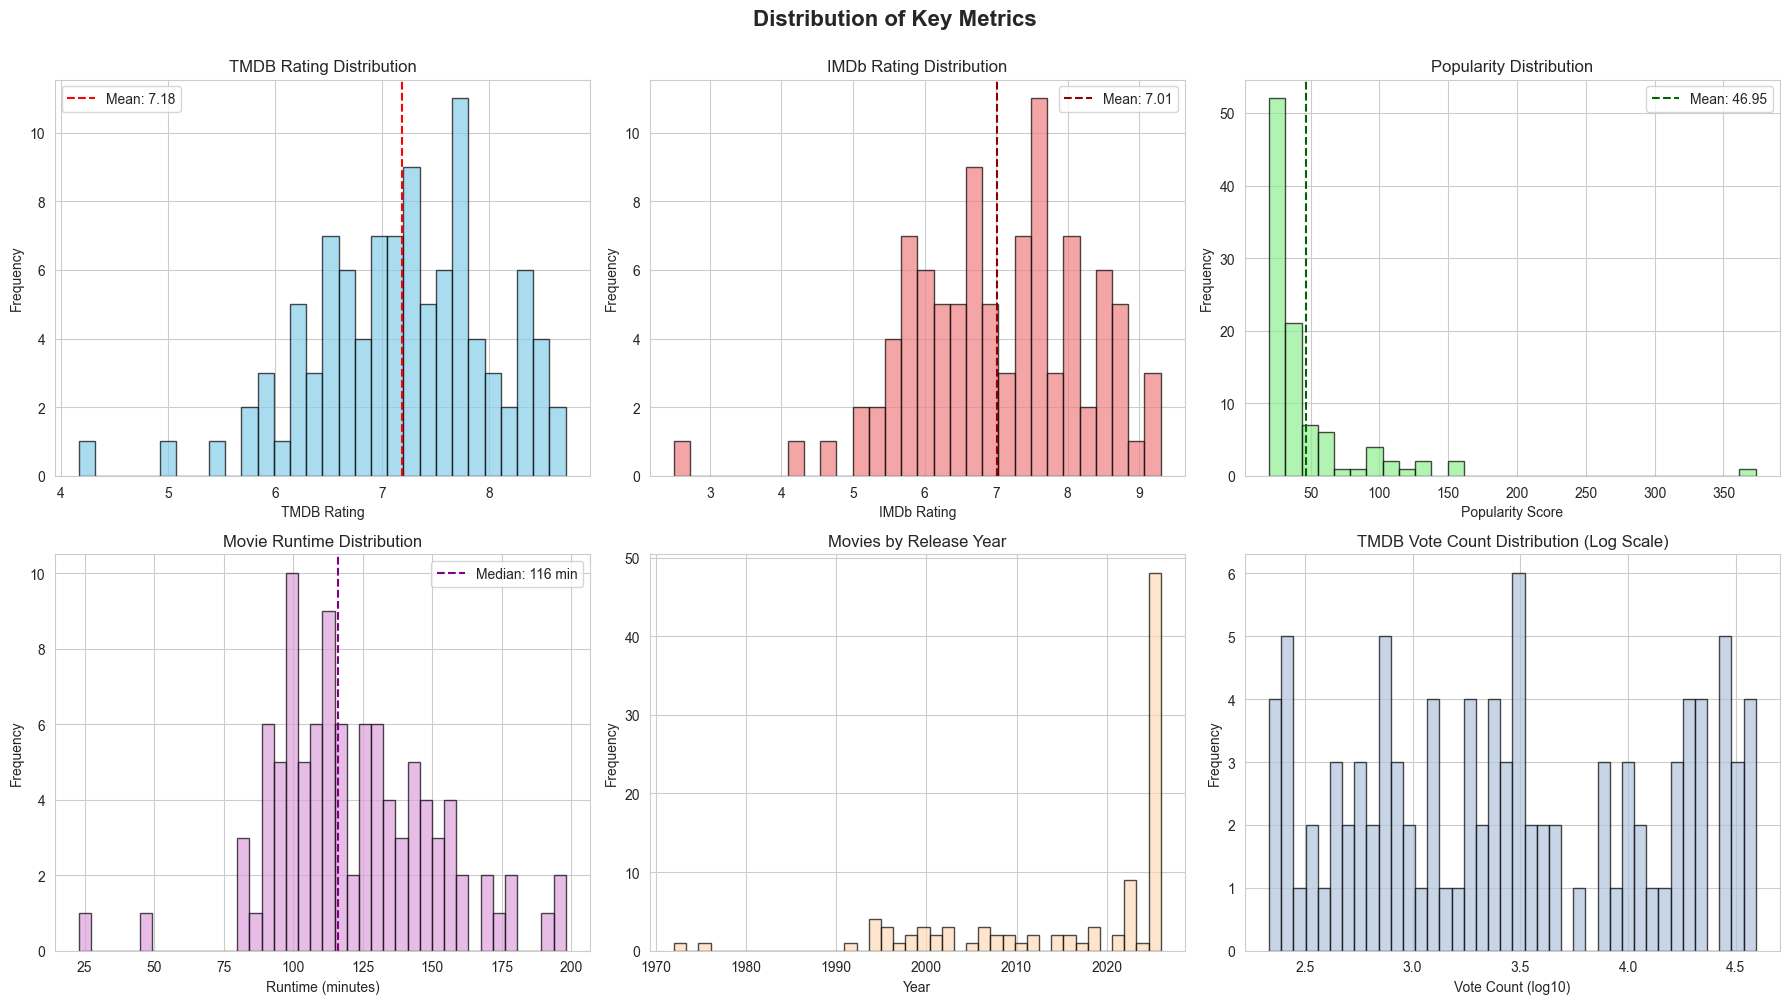

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution of Key Metrics', fontsize=16, fontweight='bold', y=1.00)

# Rating distributions
axes[0, 0].hist(viz_df['tmdb_rating'].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('TMDB Rating')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('TMDB Rating Distribution')
axes[0, 0].axvline(viz_df['tmdb_rating'].mean(), color='red', linestyle='--', label=f"Mean: {viz_df['tmdb_rating'].mean():.2f}")
axes[0, 0].legend()

axes[0, 1].hist(viz_df['imdb_rating'].dropna(), bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('IMDb Rating')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('IMDb Rating Distribution')
axes[0, 1].axvline(viz_df['imdb_rating'].mean(), color='darkred', linestyle='--', label=f"Mean: {viz_df['imdb_rating'].mean():.2f}")
axes[0, 1].legend()

axes[0, 2].hist(viz_df['popularity'].dropna(), bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel('Popularity Score')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Popularity Distribution')
axes[0, 2].axvline(viz_df['popularity'].mean(), color='darkgreen', linestyle='--', label=f"Mean: {viz_df['popularity'].mean():.2f}")
axes[0, 2].legend()

# Runtime distribution
axes[1, 0].hist(viz_df['runtime'].dropna(), bins=40, color='plum', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Runtime (minutes)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Movie Runtime Distribution')
axes[1, 0].axvline(viz_df['runtime'].median(), color='purple', linestyle='--', label=f"Median: {viz_df['runtime'].median():.0f} min")
axes[1, 0].legend()

# Year distribution
axes[1, 1].hist(viz_df['year'].dropna(), bins=40, color='peachpuff', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Movies by Release Year')

# Vote count distribution (log scale)
axes[1, 2].hist(np.log10(viz_df['tmdb_vote_count'].dropna() + 1), bins=40, color='lightsteelblue', edgecolor='black', alpha=0.7)
axes[1, 2].set_xlabel('Vote Count (log10)')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('TMDB Vote Count Distribution (Log Scale)')

plt.tight_layout()
plt.show()

## Line Plot - Movies Over Time

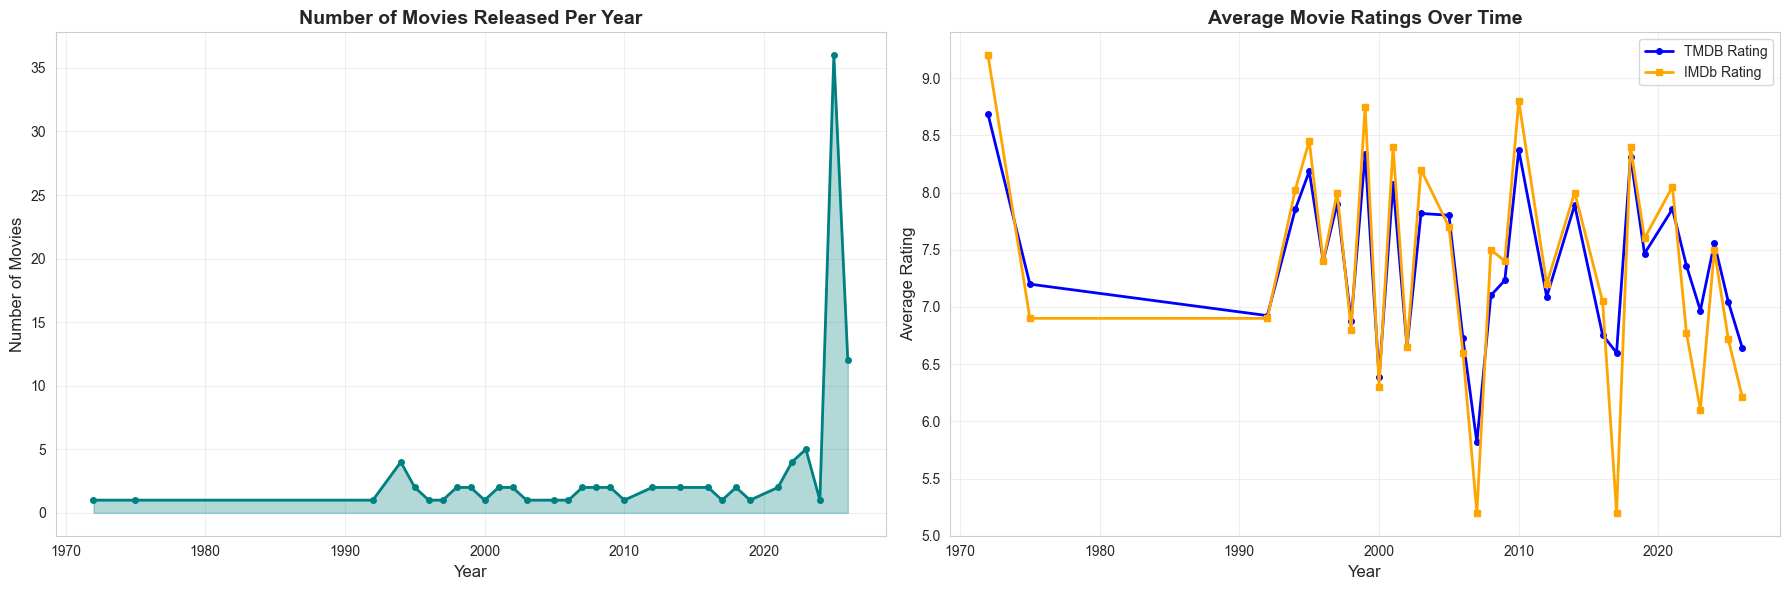

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Movies released per year
movies_per_year = viz_df.groupby('year').size().reset_index(name='count')
axes[0].plot(movies_per_year['year'], movies_per_year['count'], marker='o', linewidth=2, markersize=4, color='teal')
axes[0].fill_between(movies_per_year['year'], movies_per_year['count'], alpha=0.3, color='teal')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Number of Movies', fontsize=12)
axes[0].set_title('Number of Movies Released Per Year', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Average rating over time
rating_by_year = viz_df.dropna(subset=['year', 'rating']).groupby('year')['rating'].mean()
axes[1].plot(rating_by_year.index, rating_by_year.values, marker='o', linewidth=2, markersize=4, color='tomato')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Average Rating', fontsize=12)
axes[1].set_title('Average Rating Over Time', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Bar Plots - Top Categories

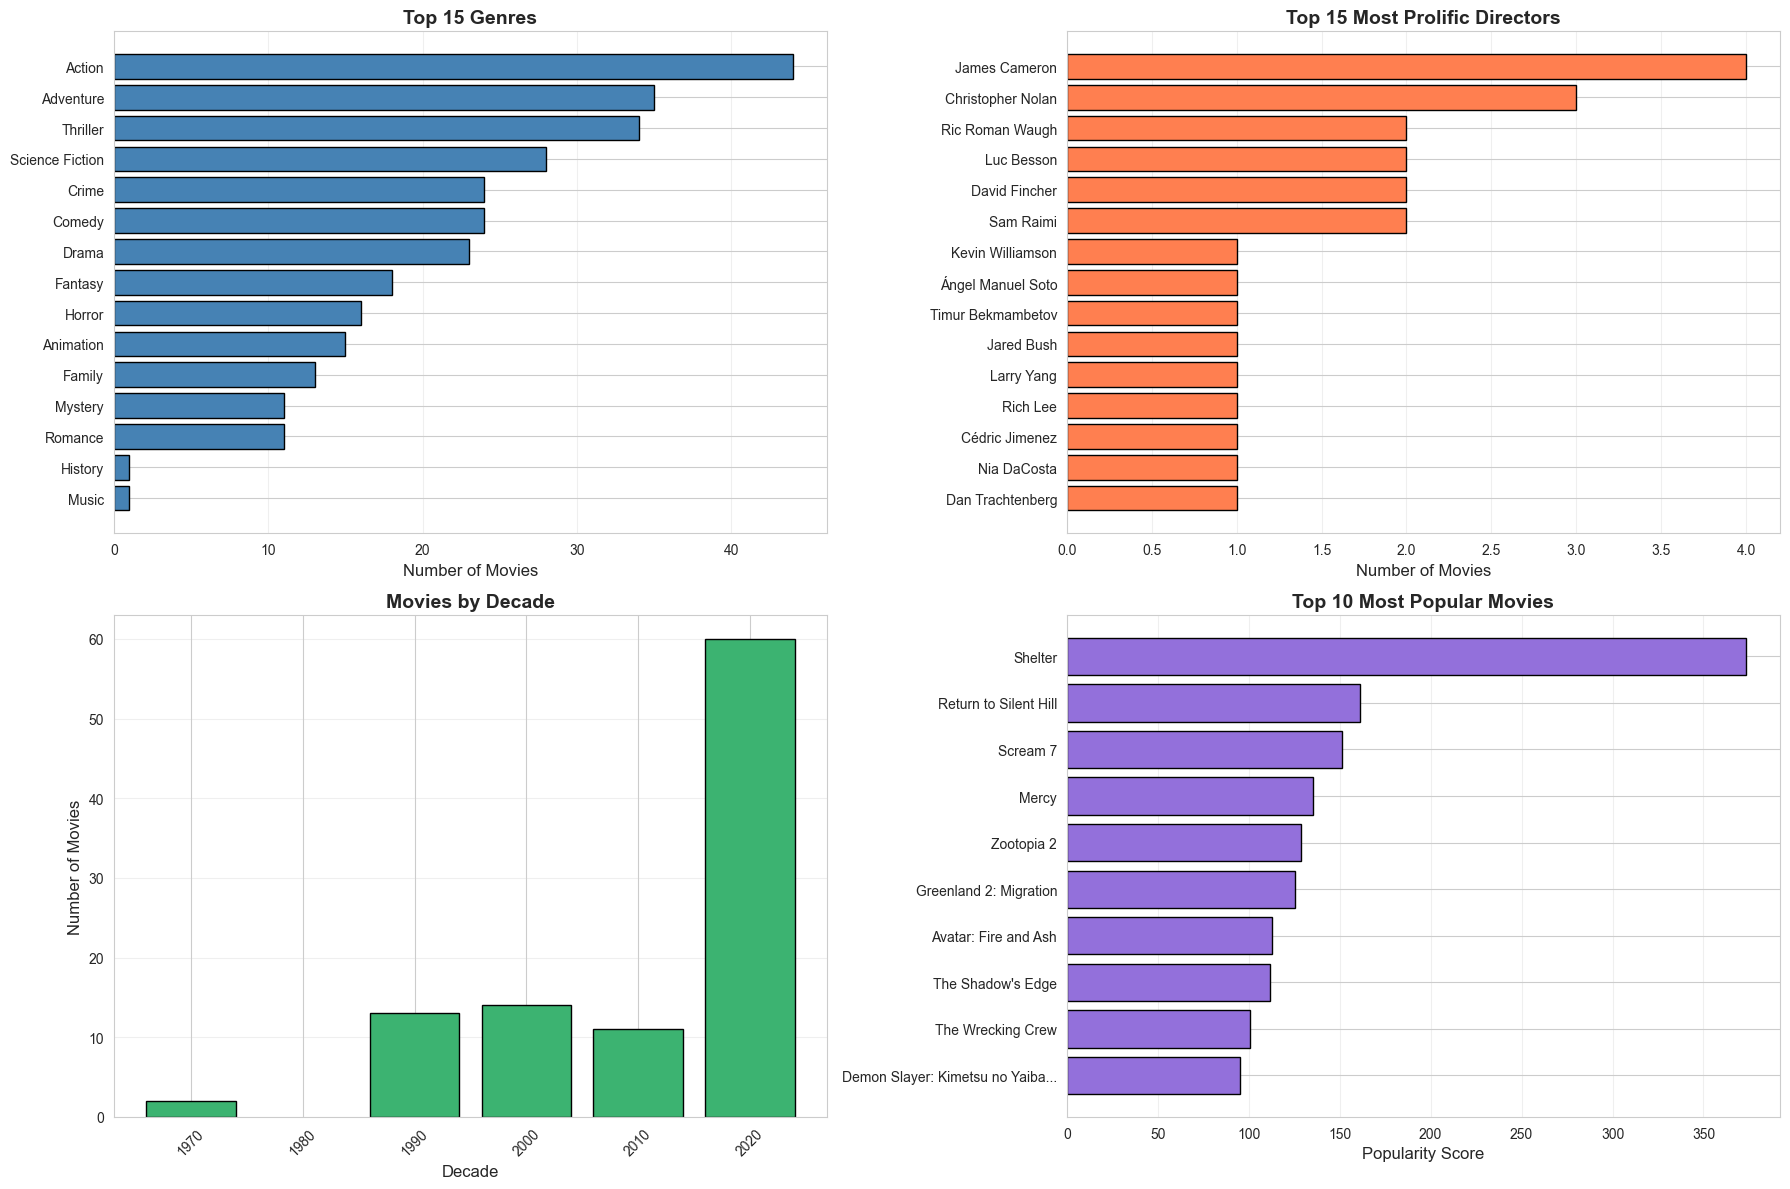

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top 15 Genres (exploded)
all_genres = []
for genres in viz_df['genres'].dropna():
    if isinstance(genres, str):
        all_genres.extend([g.strip() for g in genres.split(',')])

genre_counts = pd.Series(all_genres).value_counts().head(15)
axes[0, 0].barh(genre_counts.index[::-1], genre_counts.values[::-1], color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Number of Movies', fontsize=12)
axes[0, 0].set_title('Top 15 Genres', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Top 15 Directors
director_counts = viz_df['director'].value_counts().head(15)
axes[0, 1].barh(director_counts.index[::-1], director_counts.values[::-1], color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Number of Movies', fontsize=12)
axes[0, 1].set_title('Top 15 Most Prolific Directors', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# Movies by Decade
viz_df['decade'] = (viz_df['year'] // 10) * 10
decade_counts = viz_df['decade'].value_counts().sort_index()
axes[1, 0].bar(decade_counts.index, decade_counts.values, color='mediumseagreen', edgecolor='black', width=8)
axes[1, 0].set_xlabel('Decade', fontsize=12)
axes[1, 0].set_ylabel('Number of Movies', fontsize=12)
axes[1, 0].set_title('Movies by Decade', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Top 10 Most Popular Movies
top_popular = viz_df.nlargest(10, 'popularity')[['title', 'popularity']].sort_values('popularity')
axes[1, 1].barh(range(len(top_popular)), top_popular['popularity'].values, color='mediumpurple', edgecolor='black')
axes[1, 1].set_yticks(range(len(top_popular)))
axes[1, 1].set_yticklabels([title[:30] + '...' if len(title) > 30 else title for title in top_popular['title']], fontsize=10)
axes[1, 1].set_xlabel('Popularity Score', fontsize=12)
axes[1, 1].set_title('Top 10 Most Popular Movies', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


## Scatter Plots - Relationships

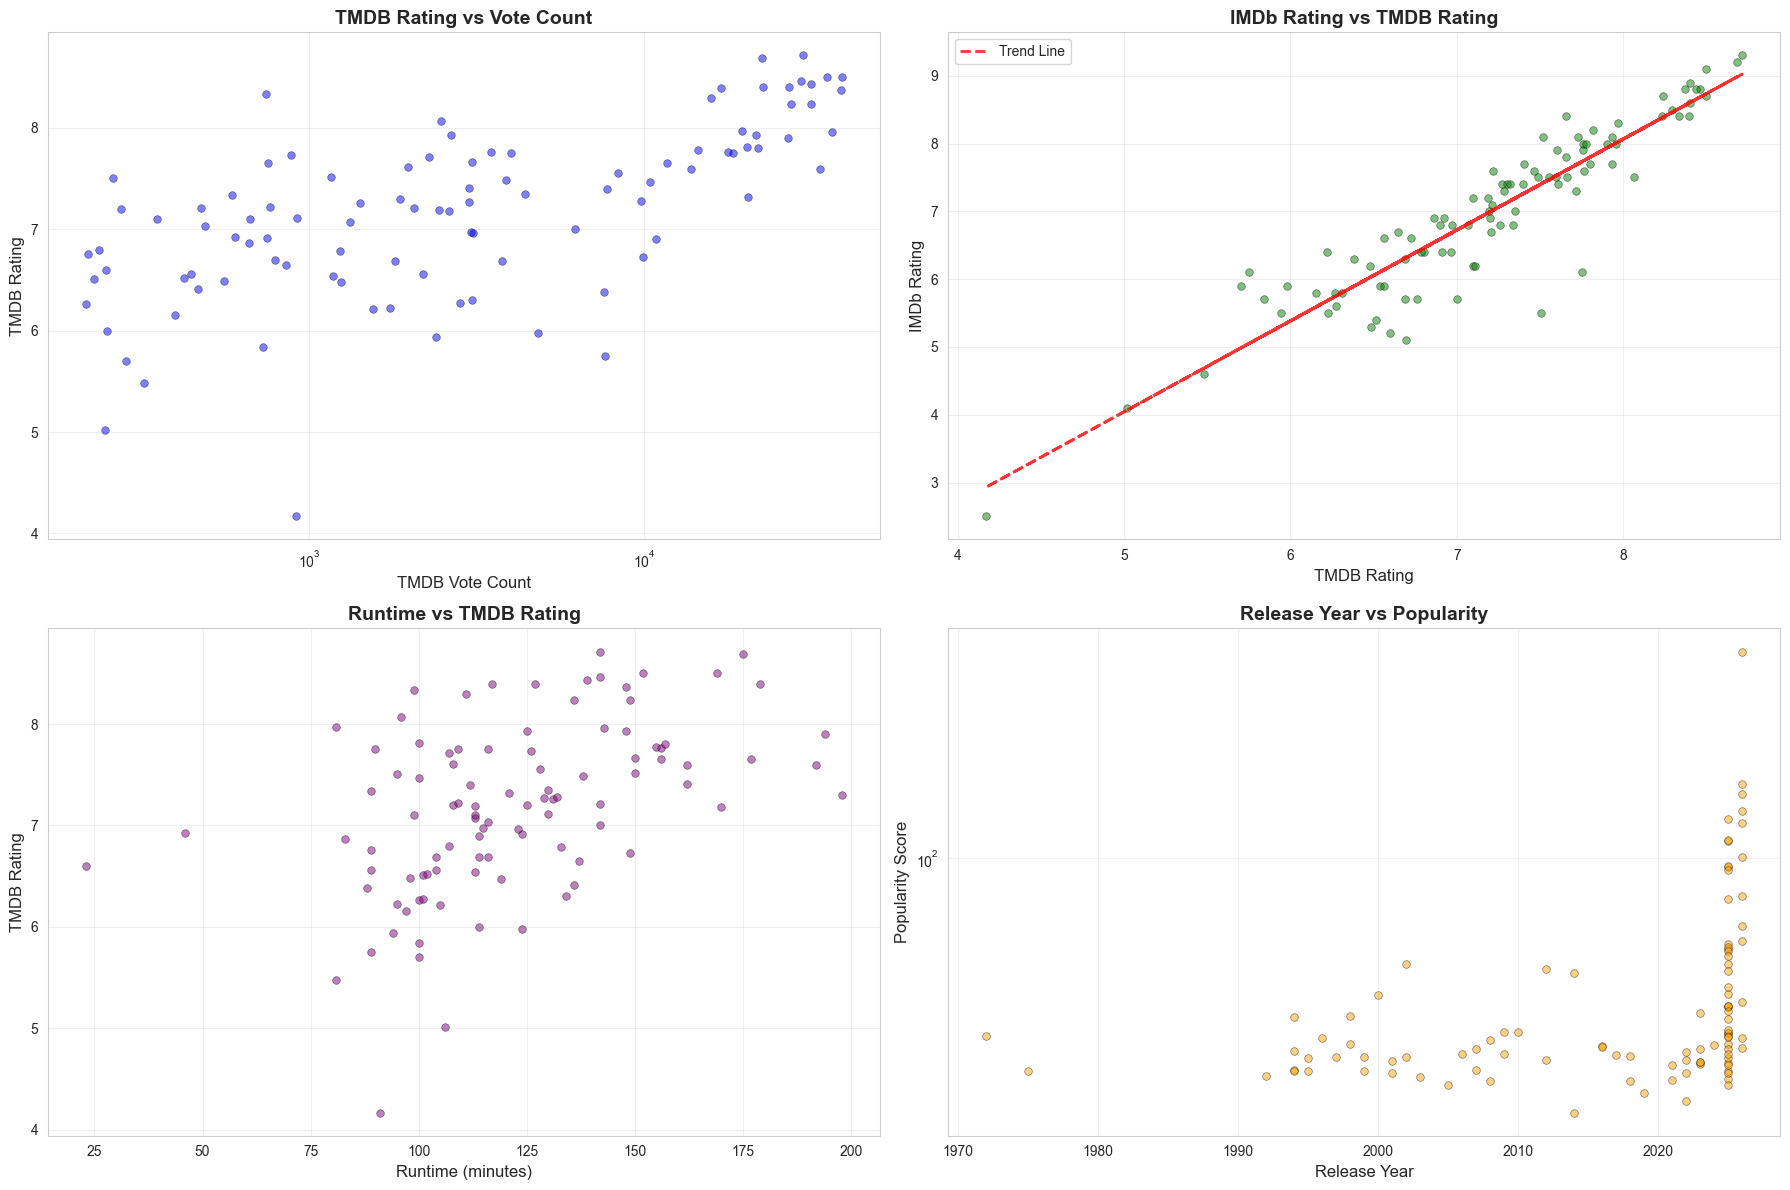

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Rating vs Vote Count
if 'vote_count' in viz_df.columns:
    axes[0, 0].scatter(viz_df['vote_count'], viz_df['rating'], alpha=0.5, s=30, c='blue', edgecolors='black', linewidth=0.5)
    axes[0, 0].set_xlabel('Vote Count', fontsize=12)
    axes[0, 0].set_ylabel('Rating', fontsize=12)
    axes[0, 0].set_title('Rating vs Vote Count', fontsize=14, fontweight='bold')
    axes[0, 0].set_xscale('log')
    axes[0, 0].grid(True, alpha=0.3)

# Rating vs Popularity
scatter_data = viz_df.dropna(subset=['rating', 'popularity'])
axes[0, 1].scatter(scatter_data['popularity'], scatter_data['rating'], alpha=0.5, s=30, c='green', edgecolors='black', linewidth=0.5)
axes[0, 1].set_xlabel('Popularity', fontsize=12)
axes[0, 1].set_ylabel('Rating', fontsize=12)
axes[0, 1].set_title('Rating vs Popularity', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Runtime vs Rating
runtime_data = viz_df.dropna(subset=['runtime', 'rating'])
axes[1, 0].scatter(runtime_data['runtime'], runtime_data['rating'], alpha=0.5, s=30, c='purple', edgecolors='black', linewidth=0.5)
axes[1, 0].set_xlabel('Runtime (minutes)', fontsize=12)
axes[1, 0].set_ylabel('Rating', fontsize=12)
axes[1, 0].set_title('Runtime vs Rating', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Year vs Popularity
axes[1, 1].scatter(viz_df['year'], viz_df['popularity'], alpha=0.5, s=30, c='orange', edgecolors='black', linewidth=0.5)
axes[1, 1].set_xlabel('Release Year', fontsize=12)
axes[1, 1].set_ylabel('Popularity Score', fontsize=12)
axes[1, 1].set_title('Release Year vs Popularity', fontsize=14, fontweight='bold')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Seaborn Box Plots - Statistical Distribution

C:\Users\mausa\AppData\Local\Temp\ipykernel_19668\3310335655.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=decade_data, x='decade', y='tmdb_rating', palette='Set2', ax=axes[0, 0])
C:\Users\mausa\AppData\Local\Temp\ipykernel_19668\3310335655.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=genre_runtime_df, x='genre', y='runtime', palette='Set3', ax=axes[0, 1])
C:\Users\mausa\AppData\Local\Temp\ipykernel_19668\3310335655.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=runtime_data, x='runtime_category', y='imdb_r

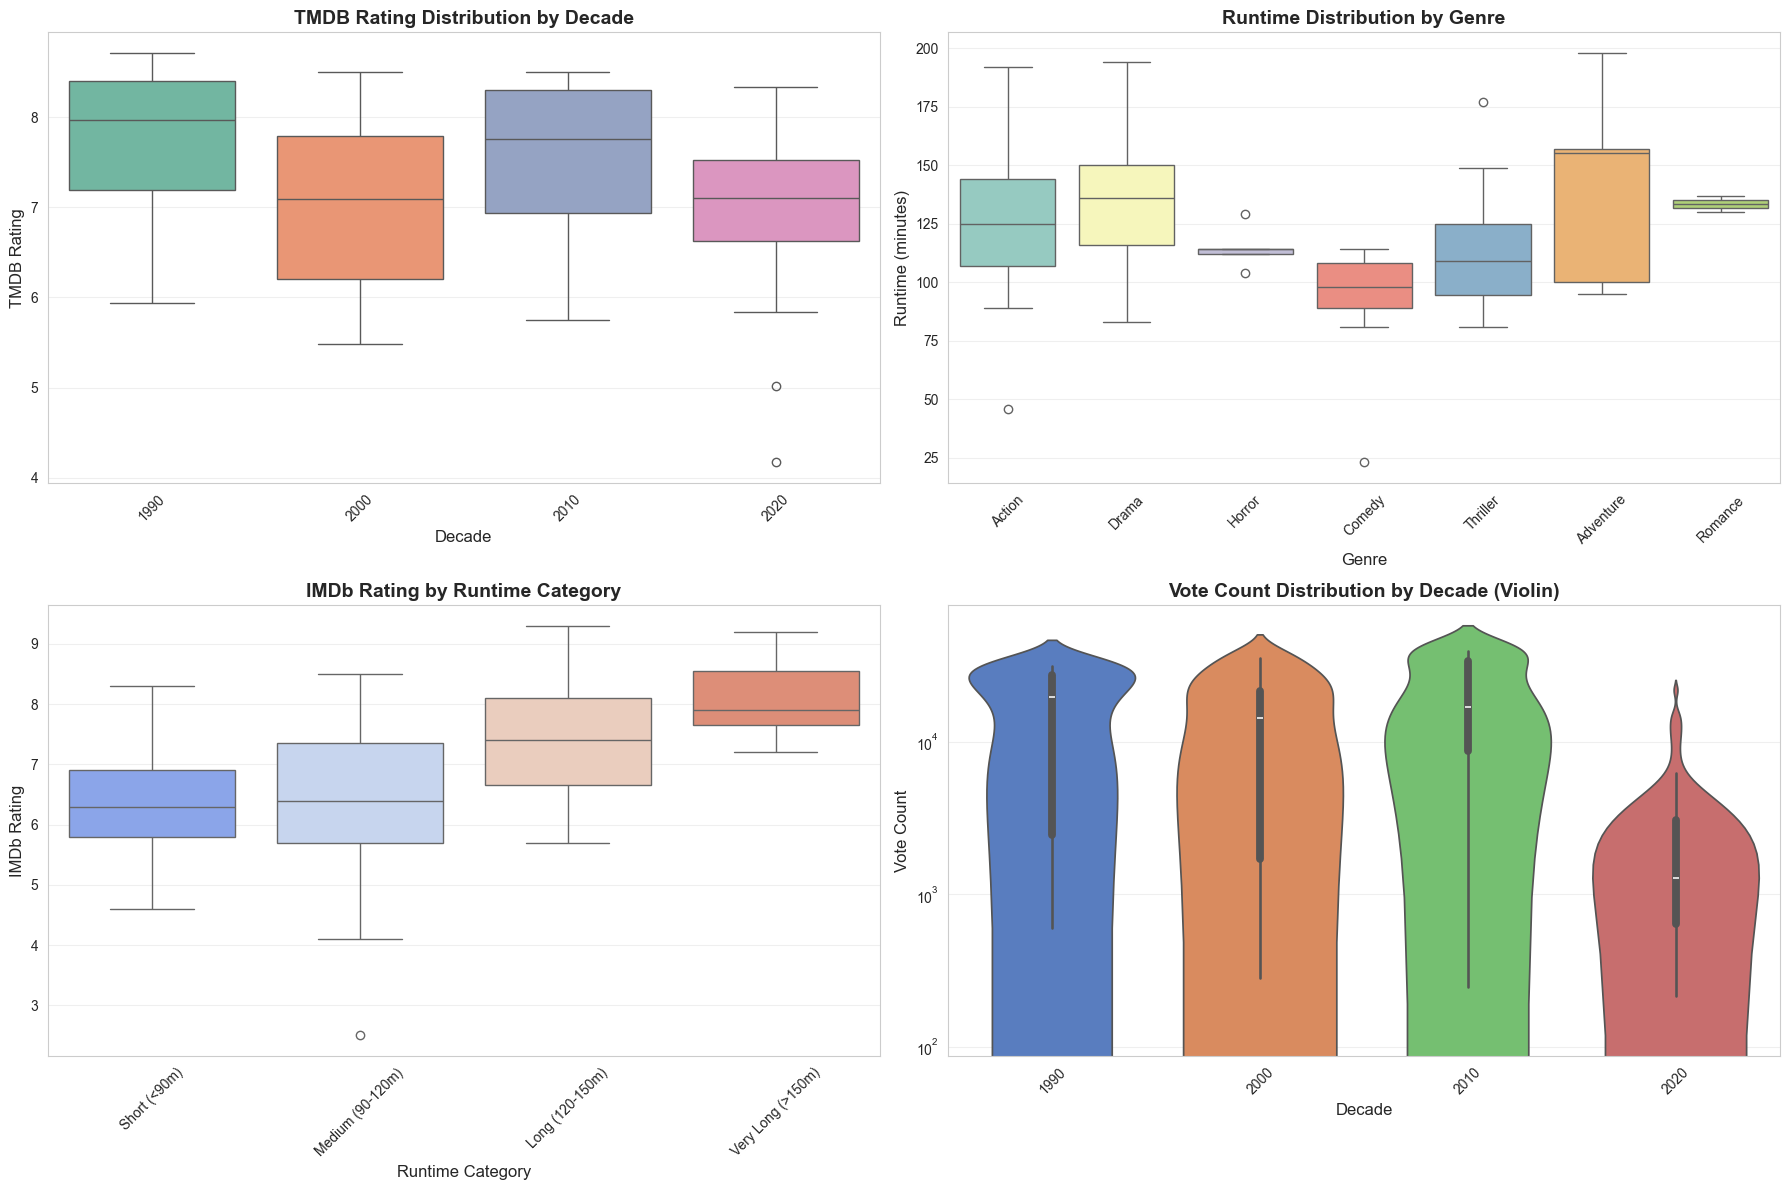

In [28]:
# Create decade column for grouping
viz_df['decade'] = (viz_df['year'] // 10 * 10).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Box plot: Ratings by Decade
decade_data = viz_df[viz_df['decade'] >= 1980].copy()
sns.boxplot(data=decade_data, x='decade', y='tmdb_rating', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_xlabel('Decade', fontsize=12)
axes[0, 0].set_ylabel('TMDB Rating', fontsize=12)
axes[0, 0].set_title('TMDB Rating Distribution by Decade', fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Box plot: Runtime by top genres
top_genres_list = ['Action', 'Drama', 'Comedy', 'Thriller', 'Romance', 'Horror', 'Adventure']
genre_runtime = []
for idx, row in viz_df.iterrows():
    if pd.notna(row['genres']) and pd.notna(row['runtime']):
        for genre in top_genres_list:
            if genre in str(row['genres']):
                genre_runtime.append({'genre': genre, 'runtime': row['runtime']})
                break

genre_runtime_df = pd.DataFrame(genre_runtime)
if not genre_runtime_df.empty:
    sns.boxplot(data=genre_runtime_df, x='genre', y='runtime', palette='Set3', ax=axes[0, 1])
    axes[0, 1].set_xlabel('Genre', fontsize=12)
    axes[0, 1].set_ylabel('Runtime (minutes)', fontsize=12)
    axes[0, 1].set_title('Runtime Distribution by Genre', fontsize=14, fontweight='bold')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(axis='y', alpha=0.3)

# Box plot: Rating by Runtime Categories
runtime_data = viz_df.dropna(subset=['runtime', 'imdb_rating']).copy()
runtime_data['runtime_category'] = pd.cut(runtime_data['runtime'], 
                                           bins=[0, 90, 120, 150, 300],
                                           labels=['Short (<90m)', 'Medium (90-120m)', 'Long (120-150m)', 'Very Long (>150m)'])
sns.boxplot(data=runtime_data, x='runtime_category', y='imdb_rating', palette='coolwarm', ax=axes[1, 0])
axes[1, 0].set_xlabel('Runtime Category', fontsize=12)
axes[1, 0].set_ylabel('IMDb Rating', fontsize=12)
axes[1, 0].set_title('IMDb Rating by Runtime Category', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Violin plot: Vote count distribution by decade
sns.violinplot(data=decade_data, x='decade', y='tmdb_vote_count', palette='muted', ax=axes[1, 1])
axes[1, 1].set_xlabel('Decade', fontsize=12)
axes[1, 1].set_ylabel('Vote Count', fontsize=12)
axes[1, 1].set_title('Vote Count Distribution by Decade (Violin)', fontsize=14, fontweight='bold')
axes[1, 1].set_yscale('log')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Seaborn Pair Plot - Multivariate Analysis

c:\Users\mausa\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
c:\Users\mausa\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
c:\Users\mausa\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
c:\Users\mausa\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecat

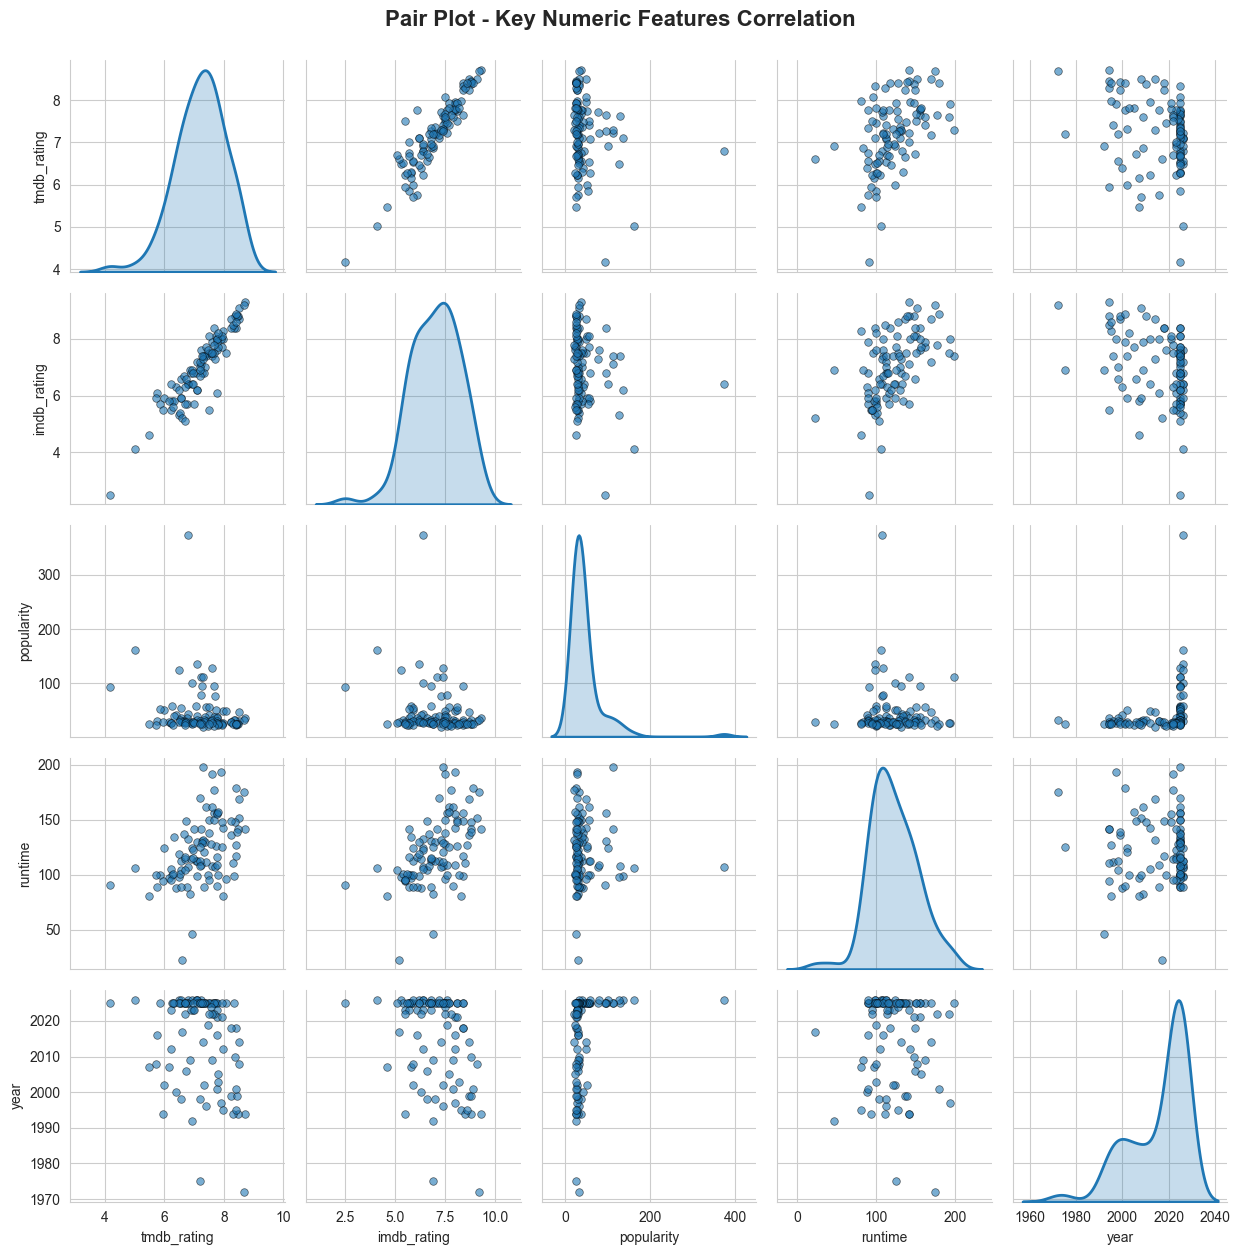


Pearson Correlation Coefficients:
             tmdb_rating  imdb_rating  popularity  runtime   year
tmdb_rating        1.000        0.921      -0.189    0.481 -0.269
imdb_rating        0.921        1.000      -0.194    0.532 -0.364
popularity        -0.189       -0.194       1.000   -0.036  0.289
runtime            0.481        0.532      -0.036    1.000 -0.031
year              -0.269       -0.364       0.289   -0.031  1.000


In [29]:
# Select key numeric columns for pair plot
pair_cols = ['tmdb_rating', 'imdb_rating', 'popularity', 'runtime', 'year']
pair_data = viz_df[pair_cols].dropna()

# Sample data if too large (for performance)
if len(pair_data) > 500:
    pair_data = pair_data.sample(500, random_state=42)

# Create pair plot
pairplot = sns.pairplot(pair_data, 
                        diag_kind='kde', 
                        plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k', 'linewidth': 0.5},
                        diag_kws={'linewidth': 2, 'shade': True})

pairplot.figure.suptitle('Pair Plot - Key Numeric Features Correlation', y=1.00, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print correlation values
print("\nPearson Correlation Coefficients:")
print("="*60)
print(pair_data.corr().round(3))

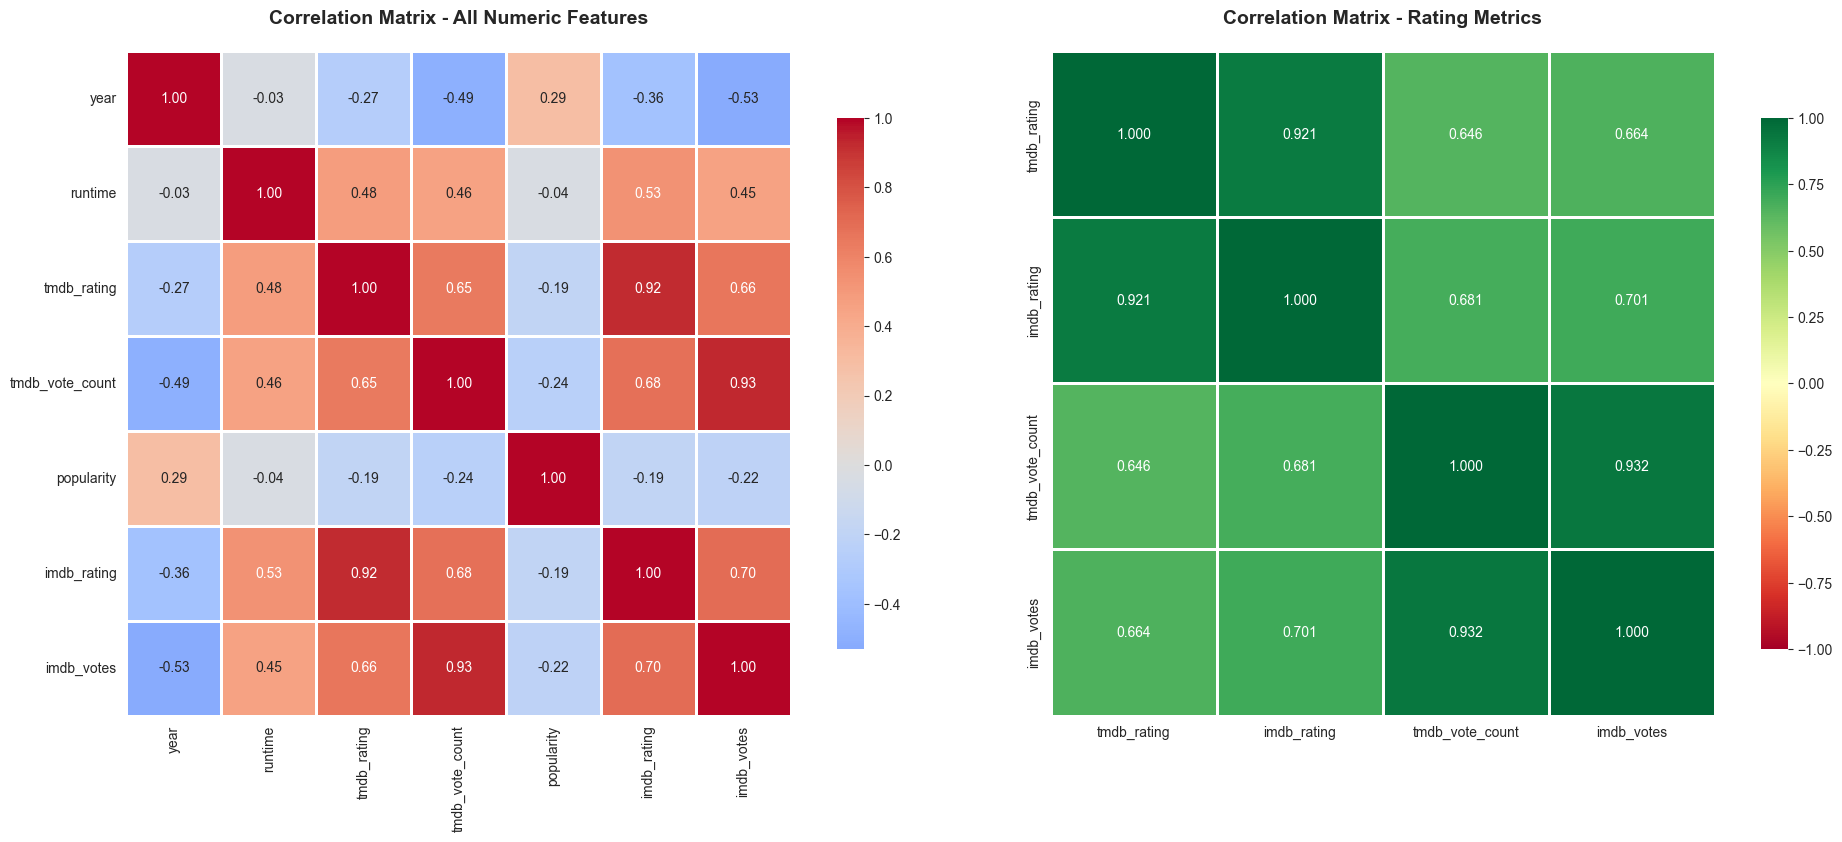


STRONGEST CORRELATIONS (|r| > 0.5)
tmdb_vote_count      <-> imdb_votes           :  0.932
tmdb_rating          <-> imdb_rating          :  0.921
imdb_rating          <-> imdb_votes           :  0.701
tmdb_vote_count      <-> imdb_rating          :  0.681
tmdb_rating          <-> imdb_votes           :  0.664
tmdb_rating          <-> tmdb_vote_count      :  0.646
runtime              <-> imdb_rating          :  0.532
year                 <-> imdb_votes           : -0.531


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Correlation heatmap for all numeric features
numeric_cols = ['year', 'runtime', 'tmdb_rating', 'tmdb_vote_count', 'popularity', 
                'imdb_rating', 'imdb_votes']
corr_data = viz_df[numeric_cols].dropna()
correlation_matrix = corr_data.corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title('Correlation Matrix - All Numeric Features', fontsize=14, fontweight='bold', pad=20)

# Focused correlation heatmap for ratings
rating_cols = ['tmdb_rating', 'imdb_rating', 'tmdb_vote_count', 'imdb_votes']
rating_corr = viz_df[rating_cols].dropna().corr()

sns.heatmap(rating_corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            square=True, linewidths=2, cbar_kws={"shrink": 0.8}, 
            vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Correlation Matrix - Rating Metrics', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Print strongest correlations
print("\n" + "="*60)
print("STRONGEST CORRELATIONS (|r| > 0.5)")
print("="*60)
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], corr_val))

corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for col1, col2, val in corr_pairs:
    print(f"{col1:20s} <-> {col2:20s} : {val:6.3f}")

## Summary Dashboard - Key Insights

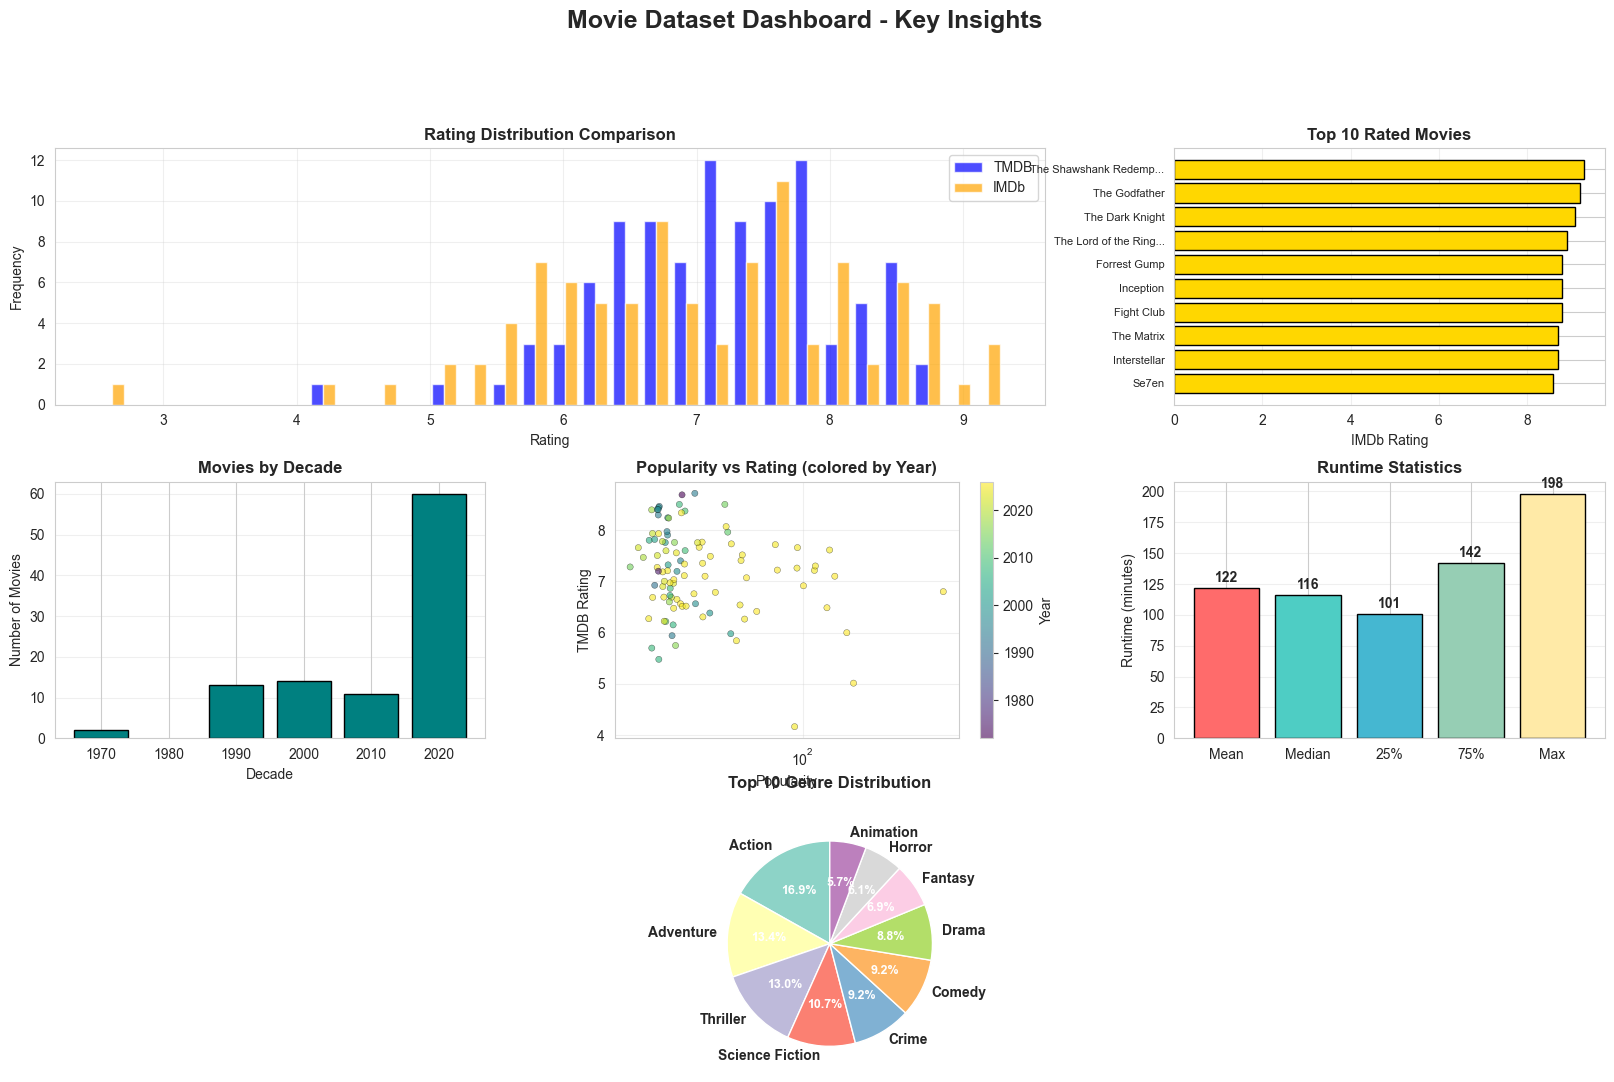


DATASET SUMMARY
Total Movies: 100
Year Range: 1972 - 2026
Average TMDB Rating: 7.18
Average IMDb Rating: 7.01
Average Runtime: 122 minutes
Most Common Genre: Action
Most Prolific Director: James Cameron (4 movies)


In [31]:
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Rating distribution comparison
ax1 = fig.add_subplot(gs[0, :2])
ax1.hist([viz_df['tmdb_rating'].dropna(), viz_df['imdb_rating'].dropna()], 
         bins=30, label=['TMDB', 'IMDb'], alpha=0.7, color=['blue', 'orange'])
ax1.set_xlabel('Rating')
ax1.set_ylabel('Frequency')
ax1.set_title('Rating Distribution Comparison', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Top 10 highest rated movies
ax2 = fig.add_subplot(gs[0, 2])
top_rated = viz_df.nlargest(10, 'imdb_rating')[['title', 'imdb_rating']].sort_values('imdb_rating')
ax2.barh(range(len(top_rated)), top_rated['imdb_rating'], color='gold', edgecolor='black')
ax2.set_yticks(range(len(top_rated)))
ax2.set_yticklabels([t[:20] + '...' if len(t) > 20 else t for t in top_rated['title']], fontsize=8)
ax2.set_xlabel('IMDb Rating')
ax2.set_title('Top 10 Rated Movies', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# 3. Movies per decade
ax3 = fig.add_subplot(gs[1, 0])
decade_counts = viz_df['decade'].value_counts().sort_index()
ax3.bar(decade_counts.index, decade_counts.values, color='teal', edgecolor='black', width=8)
ax3.set_xlabel('Decade')
ax3.set_ylabel('Number of Movies')
ax3.set_title('Movies by Decade', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Popularity vs Rating scatter
ax4 = fig.add_subplot(gs[1, 1])
scatter_data = viz_df.dropna(subset=['popularity', 'tmdb_rating'])
sc = ax4.scatter(scatter_data['popularity'], scatter_data['tmdb_rating'], 
                 c=scatter_data['year'], cmap='viridis', alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
ax4.set_xlabel('Popularity')
ax4.set_ylabel('TMDB Rating')
ax4.set_title('Popularity vs Rating (colored by Year)', fontsize=12, fontweight='bold')
ax4.set_xscale('log')
plt.colorbar(sc, ax=ax4, label='Year')
ax4.grid(alpha=0.3)

# 5. Runtime statistics
ax5 = fig.add_subplot(gs[1, 2])
runtime_stats = viz_df['runtime'].describe()
categories = ['Mean', 'Median', '25%', '75%', 'Max']
values = [runtime_stats['mean'], runtime_stats['50%'], runtime_stats['25%'], runtime_stats['75%'], runtime_stats['max']]
ax5.bar(categories, values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'], edgecolor='black')
ax5.set_ylabel('Runtime (minutes)')
ax5.set_title('Runtime Statistics', fontsize=12, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)
for i, v in enumerate(values):
    ax5.text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold')

# 6. Genre popularity (pie chart)
ax6 = fig.add_subplot(gs[2, :])
top_genres_pie = pd.Series(all_genres).value_counts().head(10)
colors = plt.cm.Set3(range(len(top_genres_pie)))
wedges, texts, autotexts = ax6.pie(top_genres_pie.values, labels=top_genres_pie.index, autopct='%1.1f%%',
                                     colors=colors, startangle=90)
for text in texts:
    text.set_fontsize(10)
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
ax6.set_title('Top 10 Genre Distribution', fontsize=12, fontweight='bold', pad=20)

fig.suptitle('Movie Dataset Dashboard - Key Insights', fontsize=18, fontweight='bold', y=0.995)
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"Total Movies: {len(viz_df)}")
print(f"Year Range: {viz_df['year'].min():.0f} - {viz_df['year'].max():.0f}")
print(f"Average TMDB Rating: {viz_df['tmdb_rating'].mean():.2f}")
print(f"Average IMDb Rating: {viz_df['imdb_rating'].mean():.2f}")
print(f"Average Runtime: {viz_df['runtime'].mean():.0f} minutes")
print(f"Most Common Genre: {pd.Series(all_genres).value_counts().index[0]}")
print(f"Most Prolific Director: {viz_df['director'].value_counts().index[0]} ({viz_df['director'].value_counts().iloc[0]} movies)")
print("="*60)

# 04 — Automated Report Generation

Generate comprehensive reports in Excel, HTML, and PDF formats.

In [32]:
# Install required packages for report generation
!pip -q install openpyxl xlsxwriter reportlab matplotlib pillow jinja2

In [33]:
from datetime import datetime
from io import BytesIO
import base64

# Create reports directory
reports_dir = Path().resolve().parent / "reports"
reports_dir.mkdir(exist_ok=True)

# Generate timestamp for report names
report_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"Report Generation Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Reports will be saved to: {reports_dir}")
print("="*60)

Report Generation Started: 2026-03-08 14:11:40
Reports will be saved to: C:\Users\mausa\Desktop\modify_1st try\reports


## Excel Report Generation

In [34]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows

# Excel file path
excel_path = reports_dir / f"movie_analysis_report_{report_timestamp}.xlsx"

# Create Excel writer with xlsxwriter engine for formatting
with pd.ExcelWriter(excel_path, engine='xlsxwriter') as writer:
    workbook = writer.book
    
    # Define formats
    header_format = workbook.add_format({
        'bold': True,
        'bg_color': '#4472C4',
        'font_color': 'white',
        'border': 1,
        'align': 'center',
        'valign': 'vcenter'
    })
    
    title_format = workbook.add_format({
        'bold': True,
        'font_size': 14,
        'bg_color': '#D9E1F2',
        'border': 1
    })
    
    # Sheet 1: Summary Statistics
    summary_df = pd.DataFrame({
        'Metric': [
            'Total Movies',
            'Year Range',
            'Average TMDB Rating',
            'Average IMDb Rating',
            'Average Popularity',
            'Average Runtime (min)',
            'Total Directors',
            'Total Genres',
            'Most Common Genre',
            'Most Prolific Director'
        ],
        'Value': [
            len(viz_df),
            f"{viz_df['year'].min():.0f} - {viz_df['year'].max():.0f}",
            f"{viz_df['tmdb_rating'].mean():.2f}",
            f"{viz_df['imdb_rating'].mean():.2f}",
            f"{viz_df['popularity'].mean():.2f}",
            f"{viz_df['runtime'].mean():.0f}",
            viz_df['director'].nunique(),
            len(set(all_genres)),
            pd.Series(all_genres).value_counts().index[0],
            viz_df['director'].value_counts().index[0]
        ]
    })
    summary_df.to_excel(writer, sheet_name='Summary', index=False)
    worksheet = writer.sheets['Summary']
    worksheet.set_column('A:A', 30)
    worksheet.set_column('B:B', 30)
    for col_num, value in enumerate(summary_df.columns.values):
        worksheet.write(0, col_num, value, header_format)
    
    # Sheet 2: Top 50 Rated Movies
    top_movies_cols = ['title', 'year', 'director', 'genres', 'imdb_rating', 'tmdb_rating', 'runtime']
    # Only include columns that exist
    available_top_cols = [col for col in top_movies_cols if col in viz_df.columns]
    top_movies = viz_df.nlargest(50, 'imdb_rating')[available_top_cols].copy()
    top_movies.to_excel(writer, sheet_name='Top Movies', index=False)
    worksheet = writer.sheets['Top Movies']
    worksheet.set_column('A:A', 40)
    worksheet.set_column('B:B', 10)
    worksheet.set_column('C:C', 25)
    worksheet.set_column('D:D', 30)
    for col_num, value in enumerate(top_movies.columns.values):
        worksheet.write(0, col_num, value, header_format)
    
    # Sheet 3: Genre Analysis
    genre_counts = pd.Series(all_genres).value_counts().reset_index()
    genre_counts.columns = ['Genre', 'Count']
    genre_rating = []
    for genre in genre_counts['Genre']:
        genre_movies = viz_df[viz_df['genres'].str.contains(genre, na=False)]
        avg_rating = genre_movies['imdb_rating'].mean()
        genre_rating.append(avg_rating)
    genre_counts['Avg IMDb Rating'] = genre_rating
    genre_counts.to_excel(writer, sheet_name='Genre Analysis', index=False)
    worksheet = writer.sheets['Genre Analysis']
    worksheet.set_column('A:A', 20)
    worksheet.set_column('B:C', 15)
    for col_num, value in enumerate(genre_counts.columns.values):
        worksheet.write(0, col_num, value, header_format)
    
    # Sheet 4: Director Statistics
    director_stats = viz_df.groupby('director').agg({
        'title': 'count',
        'imdb_rating': 'mean',
        'tmdb_rating': 'mean',
        'runtime': 'mean'
    }).round(2).sort_values('title', ascending=False).head(50)
    director_stats.columns = ['Movie Count', 'Avg IMDb Rating', 'Avg TMDB Rating', 'Avg Runtime']
    director_stats.to_excel(writer, sheet_name='Top Directors', index=True)
    worksheet = writer.sheets['Top Directors']
    worksheet.set_column('A:A', 25)
    worksheet.set_column('B:E', 15)
    
    # Sheet 5: Year-wise Analysis
    year_stats = viz_df.groupby('year').agg({
        'title': 'count',
        'imdb_rating': 'mean',
        'tmdb_rating': 'mean',
        'runtime': 'mean',
        'popularity': 'mean'
    }).round(2).sort_index(ascending=False)
    year_stats.columns = ['Movies Released', 'Avg IMDb Rating', 'Avg TMDB Rating', 'Avg Runtime', 'Avg Popularity']
    year_stats.to_excel(writer, sheet_name='Year Analysis', index=True)
    worksheet = writer.sheets['Year Analysis']
    worksheet.set_column('A:A', 12)
    worksheet.set_column('B:F', 15)
    
    # Sheet 6: Full Dataset (first 1000 rows)
    export_cols = ['title', 'year', 'director', 'genres', 'runtime', 'imdb_rating', 
                   'tmdb_rating', 'popularity', 'overview']
    # Only include columns that exist
    available_export_cols = [col for col in export_cols if col in viz_df.columns]
    full_data = viz_df[available_export_cols].head(1000)
    full_data.to_excel(writer, sheet_name='Full Data', index=False)
    worksheet = writer.sheets['Full Data']
    worksheet.set_column('A:A', 40)
    worksheet.set_column('B:B', 10)
    worksheet.set_column('C:C', 25)
    worksheet.set_column('D:D', 30)
    worksheet.set_column('E:I', 12)
    if 'overview' in available_export_cols:
        worksheet.set_column('J:J', 50)
    for col_num, value in enumerate(full_data.columns.values):
        worksheet.write(0, col_num, value, header_format)

print(f"✓ Excel Report Generated: {excel_path.name}")
print(f"  Sheets: Summary, Top Movies, Genre Analysis, Top Directors, Year Analysis, Full Data")

✓ Excel Report Generated: movie_analysis_report_20260308_141140.xlsx
  Sheets: Summary, Top Movies, Genre Analysis, Top Directors, Year Analysis, Full Data


## HTML Report Generation

In [35]:
# Generate visualizations for HTML report
def plot_to_base64(fig):
    """Convert matplotlib figure to base64 string for embedding in HTML"""
    buf = BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    img_str = base64.b64encode(buf.read()).decode()
    buf.close()
    return img_str

# Chart 1: Rating Distribution
fig1, ax = plt.subplots(figsize=(10, 5))
ax.hist([viz_df['tmdb_rating'].dropna(), viz_df['imdb_rating'].dropna()], 
        bins=25, label=['TMDB', 'IMDb'], alpha=0.7, color=['#4472C4', '#ED7D31'])
ax.set_xlabel('Rating', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Rating Distribution Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
chart1_base64 = plot_to_base64(fig1)
plt.close(fig1)

# Chart 2: Genre Distribution
fig2, ax = plt.subplots(figsize=(10, 6))
genre_counts_top = pd.Series(all_genres).value_counts().head(12)
ax.barh(genre_counts_top.index[::-1], genre_counts_top.values[::-1], color='#70AD47', edgecolor='black')
ax.set_xlabel('Number of Movies', fontsize=12)
ax.set_title('Top 12 Genres', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
chart2_base64 = plot_to_base64(fig2)
plt.close(fig2)

# Chart 3: Movies Over Time
fig3, ax = plt.subplots(figsize=(10, 5))
movies_per_year = viz_df.groupby('year').size().reset_index(name='count')
ax.plot(movies_per_year['year'], movies_per_year['count'], marker='o', linewidth=2, 
        markersize=4, color='#5B9BD5')
ax.fill_between(movies_per_year['year'], movies_per_year['count'], alpha=0.3, color='#5B9BD5')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)
ax.set_title('Movies Released Per Year', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
chart3_base64 = plot_to_base64(fig3)
plt.close(fig3)

# Chart 4: Correlation Heatmap
fig4, ax = plt.subplots(figsize=(10, 8))
rating_cols = ['tmdb_rating', 'imdb_rating', 'popularity', 'tmdb_vote_count', 'imdb_votes']
# Only include columns that exist
available_rating_cols = [col for col in rating_cols if col in viz_df.columns]
rating_corr = viz_df[available_rating_cols].dropna().corr()
sns.heatmap(rating_corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=2, cbar_kws={"shrink": 0.8}, 
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix - Rating Metrics', fontsize=14, fontweight='bold', pad=20)
chart4_base64 = plot_to_base64(fig4)
plt.close(fig4)

print("✓ Generated 4 charts for HTML report")

✓ Generated 4 charts for HTML report


In [36]:
# Generate HTML Report
html_path = reports_dir / f"movie_analysis_report_{report_timestamp}.html"

# Prepare data tables
top_movies_cols = ['title', 'year', 'director', 'imdb_rating', 'tmdb_rating']
# Only include columns that exist
available_top_cols = [col for col in top_movies_cols if col in viz_df.columns]
top_movies_html = viz_df.nlargest(20, 'imdb_rating')[available_top_cols].to_html(index=False, classes='data-table', border=0)

genre_analysis_html = genre_counts.head(15).to_html(index=False, classes='data-table', border=0)

director_stats_html = viz_df.groupby('director').agg({
    'title': 'count',
    'imdb_rating': 'mean'
}).round(2).sort_values('title', ascending=False).head(15).rename(
    columns={'title': 'Movie Count', 'imdb_rating': 'Avg Rating'}
).to_html(classes='data-table', border=0)

# HTML Template
html_content = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Movie Analysis Report</title>
    <style>
        * {{
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }}
        body {{
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            padding: 20px;
            color: #333;
        }}
        .container {{
            max-width: 1400px;
            margin: 0 auto;
            background: white;
            border-radius: 15px;
            box-shadow: 0 10px 40px rgba(0,0,0,0.3);
            overflow: hidden;
        }}
        .header {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 40px;
            text-align: center;
        }}
        .header h1 {{
            font-size: 2.5em;
            margin-bottom: 10px;
            text-shadow: 2px 2px 4px rgba(0,0,0,0.3);
        }}
        .header p {{
            font-size: 1.1em;
            opacity: 0.9;
        }}
        .summary {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
            gap: 20px;
            padding: 40px;
            background: #f8f9fa;
        }}
        .summary-card {{
            background: white;
            padding: 25px;
            border-radius: 10px;
            box-shadow: 0 4px 6px rgba(0,0,0,0.1);
            text-align: center;
            border-left: 4px solid #667eea;
        }}
        .summary-card h3 {{
            color: #667eea;
            font-size: 2em;
            margin-bottom: 10px;
        }}
        .summary-card p {{
            color: #666;
            font-size: 0.9em;
        }}
        .section {{
            padding: 40px;
        }}
        .section h2 {{
            color: #667eea;
            border-bottom: 3px solid #667eea;
            padding-bottom: 10px;
            margin-bottom: 25px;
            font-size: 1.8em;
        }}
        .chart {{
            margin: 30px 0;
            text-align: center;
        }}
        .chart img {{
            max-width: 100%;
            border-radius: 10px;
            box-shadow: 0 4px 6px rgba(0,0,0,0.1);
        }}
        .data-table {{
            width: 100%;
            border-collapse: collapse;
            margin: 20px 0;
            box-shadow: 0 4px 6px rgba(0,0,0,0.1);
            border-radius: 10px;
            overflow: hidden;
        }}
        .data-table thead {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
        }}
        .data-table th {{
            padding: 15px;
            text-align: left;
            font-weight: 600;
        }}
        .data-table td {{
            padding: 12px 15px;
            border-bottom: 1px solid #ddd;
        }}
        .data-table tbody tr:hover {{
            background-color: #f5f5f5;
        }}
        .data-table tbody tr:nth-child(even) {{
            background-color: #f9f9f9;
        }}
        .footer {{
            background: #2c3e50;
            color: white;
            text-align: center;
            padding: 20px;
            font-size: 0.9em;
        }}
        .grid-2 {{
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 30px;
            margin: 20px 0;
        }}
        @media (max-width: 768px) {{
            .grid-2 {{
                grid-template-columns: 1fr;
            }}
        }}
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>🎬 Movie Dataset Analysis Report</h1>
            <p>Generated on {datetime.now().strftime('%B %d, %Y at %H:%M:%S')}</p>
        </div>
        
        <div class="summary">
            <div class="summary-card">
                <h3>{len(viz_df)}</h3>
                <p>Total Movies</p>
            </div>
            <div class="summary-card">
                <h3>{viz_df['imdb_rating'].mean():.2f}</h3>
                <p>Avg IMDb Rating</p>
            </div>
            <div class="summary-card">
                <h3>{viz_df['tmdb_rating'].mean():.2f}</h3>
                <p>Avg TMDB Rating</p>
            </div>
            <div class="summary-card">
                <h3>{viz_df['runtime'].mean():.0f} min</h3>
                <p>Avg Runtime</p>
            </div>
            <div class="summary-card">
                <h3>{int(viz_df['year'].min())}-{int(viz_df['year'].max())}</h3>
                <p>Year Range</p>
            </div>
            <div class="summary-card">
                <h3>{viz_df['director'].nunique()}</h3>
                <p>Unique Directors</p>
            </div>
        </div>
        
        <div class="section">
            <h2>📊 Visual Analytics</h2>
            
            <div class="chart">
                <img src="data:image/png;base64,{chart1_base64}" alt="Rating Distribution">
            </div>
            
            <div class="grid-2">
                <div class="chart">
                    <img src="data:image/png;base64,{chart2_base64}" alt="Genre Distribution">
                </div>
                <div class="chart">
                    <img src="data:image/png;base64,{chart3_base64}" alt="Movies Over Time">
                </div>
            </div>
            
            <div class="chart">
                <img src="data:image/png;base64,{chart4_base64}" alt="Correlation Heatmap">
            </div>
        </div>
        
        <div class="section">
            <h2>🏆 Top 20 Rated Movies</h2>
            {top_movies_html}
        </div>
        
        <div class="section">
            <h2>🎭 Genre Analysis</h2>
            {genre_analysis_html}
        </div>
        
        <div class="section">
            <h2>🎬 Top 15 Directors</h2>
            {director_stats_html}
        </div>
        
        <div class="footer">
            <p>Movie Analysis Report | Data Science Project | {datetime.now().year}</p>
        </div>
    </div>
</body>
</html>
"""

# Save HTML report
with open(html_path, 'w', encoding='utf-8') as f:
    f.write(html_content)

print(f"✓ HTML Report Generated: {html_path.name}")
print(f"  Includes: Summary stats, 4 charts, top movies, genre analysis, director stats")

✓ HTML Report Generated: movie_analysis_report_20260308_141140.html
  Includes: Summary stats, 4 charts, top movies, genre analysis, director stats


## PDF Report Generation

In [37]:
from reportlab.lib.pagesizes import letter, A4
from reportlab.lib import colors
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer, PageBreak, Image
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_LEFT

# PDF file path
pdf_path = reports_dir / f"movie_analysis_report_{report_timestamp}.pdf"

# Create PDF document
doc = SimpleDocTemplate(str(pdf_path), pagesize=letter,
                        topMargin=0.5*inch, bottomMargin=0.5*inch,
                        leftMargin=0.75*inch, rightMargin=0.75*inch)

# Get styles and create custom styles
styles = getSampleStyleSheet()
title_style = ParagraphStyle(
    'CustomTitle',
    parent=styles['Heading1'],
    fontSize=24,
    textColor=colors.HexColor('#667eea'),
    spaceAfter=30,
    alignment=TA_CENTER,
    fontName='Helvetica-Bold'
)

heading_style = ParagraphStyle(
    'CustomHeading',
    parent=styles['Heading2'],
    fontSize=16,
    textColor=colors.HexColor('#667eea'),
    spaceAfter=12,
    spaceBefore=12,
    fontName='Helvetica-Bold'
)

# Story (PDF content)
story = []

# Title
story.append(Paragraph("Movie Dataset Analysis Report", title_style))
story.append(Paragraph(f"Generated on {datetime.now().strftime('%B %d, %Y')}", styles['Normal']))
story.append(Spacer(1, 0.3*inch))

# Summary Statistics
story.append(Paragraph("Executive Summary", heading_style))
summary_data = [
    ['Metric', 'Value'],
    ['Total Movies', f"{len(viz_df):,}"],
    ['Year Range', f"{int(viz_df['year'].min())} - {int(viz_df['year'].max())}"],
    ['Average IMDb Rating', f"{viz_df['imdb_rating'].mean():.2f}"],
    ['Average TMDB Rating', f"{viz_df['tmdb_rating'].mean():.2f}"],
    ['Average Popularity', f"{viz_df['popularity'].mean():.2f}"],
    ['Average Runtime', f"{viz_df['runtime'].mean():.0f} minutes"],
    ['Unique Directors', f"{viz_df['director'].nunique():,}"],
    ['Unique Genres', f"{len(set(all_genres))}"],
]

summary_table = Table(summary_data, colWidths=[3.5*inch, 2.5*inch])
summary_table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#667eea')),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('ALIGN', (0, 0), (-1, -1), 'LEFT'),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('FONTSIZE', (0, 0), (-1, 0), 12),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
    ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
    ('GRID', (0, 0), (-1, -1), 1, colors.grey),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, colors.lightgrey]),
]))
story.append(summary_table)
story.append(Spacer(1, 0.3*inch))

# Top 15 Rated Movies
story.append(Paragraph("Top 15 Rated Movies", heading_style))
top_movies_data = [['Title', 'Year', 'Director', 'IMDb', 'TMDB']]
for _, row in viz_df.nlargest(15, 'imdb_rating').iterrows():
    title = row['title'][:40] + '...' if len(str(row['title'])) > 40 else row['title']
    director = str(row['director'])[:20] + '...' if len(str(row['director'])) > 20 else str(row['director'])
    top_movies_data.append([
        title,
        str(int(row['year'])),
        director,
        f"{row['imdb_rating']:.1f}",
        f"{row['tmdb_rating']:.1f}"
    ])

top_movies_table = Table(top_movies_data, colWidths=[2.5*inch, 0.6*inch, 1.8*inch, 0.6*inch, 0.6*inch])
top_movies_table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#667eea')),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('ALIGN', (0, 0), (-1, -1), 'LEFT'),
    ('ALIGN', (1, 0), (-1, -1), 'CENTER'),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('FONTSIZE', (0, 0), (-1, 0), 10),
    ('FONTSIZE', (0, 1), (-1, -1), 8),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 8),
    ('GRID', (0, 0), (-1, -1), 0.5, colors.grey),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, colors.lightgrey]),
]))
story.append(top_movies_table)
story.append(PageBreak())

# Genre Analysis
story.append(Paragraph("Genre Analysis", heading_style))
genre_data = [['Genre', 'Count', 'Avg IMDb Rating']]
for _, row in genre_counts.head(20).iterrows():
    genre_data.append([
        row['Genre'],
        str(int(row['Count'])),
        f"{row['Avg IMDb Rating']:.2f}"
    ])

genre_table = Table(genre_data, colWidths=[2.5*inch, 1.5*inch, 2*inch])
genre_table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#667eea')),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('ALIGN', (0, 0), (-1, -1), 'LEFT'),
    ('ALIGN', (1, 0), (-1, -1), 'CENTER'),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('FONTSIZE', (0, 0), (-1, 0), 10),
    ('FONTSIZE', (0, 1), (-1, -1), 9),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 8),
    ('GRID', (0, 0), (-1, -1), 0.5, colors.grey),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, colors.lightgrey]),
]))
story.append(genre_table)
story.append(Spacer(1, 0.3*inch))

# Top Directors
story.append(Paragraph("Top 15 Directors", heading_style))
director_data = [['Director', 'Movie Count', 'Avg IMDb Rating']]
for director, row in viz_df.groupby('director').agg({
    'title': 'count',
    'imdb_rating': 'mean'
}).sort_values('title', ascending=False).head(15).iterrows():
    director_name = director[:35] + '...' if len(director) > 35 else director
    director_data.append([
        director_name,
        str(int(row['title'])),
        f"{row['imdb_rating']:.2f}"
    ])

director_table = Table(director_data, colWidths=[3*inch, 1.5*inch, 1.5*inch])
director_table.setStyle(TableStyle([
    ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#667eea')),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('ALIGN', (0, 0), (-1, -1), 'LEFT'),
    ('ALIGN', (1, 0), (-1, -1), 'CENTER'),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('FONTSIZE', (0, 0), (-1, 0), 10),
    ('FONTSIZE', (0, 1), (-1, -1), 9),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 8),
    ('GRID', (0, 0), (-1, -1), 0.5, colors.grey),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, colors.lightgrey]),
]))
story.append(director_table)

# Footer
story.append(Spacer(1, 0.5*inch))
footer_text = f"<para align=center><font size=8>Movie Analysis Report | Generated using Python, Pandas, and ReportLab | {datetime.now().year}</font></para>"
story.append(Paragraph(footer_text, styles['Normal']))

# Build PDF
doc.build(story)

print(f"✓ PDF Report Generated: {pdf_path.name}")
print(f"  Includes: Summary, top movies, genre analysis, director statistics")

✓ PDF Report Generated: movie_analysis_report_20260308_141140.pdf
  Includes: Summary, top movies, genre analysis, director statistics


## Report Generation Summary

In [38]:
import os

print("\n" + "="*70)
print("REPORT GENERATION COMPLETED SUCCESSFULLY")
print("="*70)
print(f"\n📁 Reports Directory: {reports_dir}")
print(f"\n📊 Generated Reports:")
print(f"\n   1. Excel Report:")
print(f"      File: {excel_path.name}")
print(f"      Size: {os.path.getsize(excel_path) / 1024:.2f} KB")
print(f"      Sheets: 6 (Summary, Top Movies, Genre Analysis, Top Directors, Year Analysis, Full Data)")

print(f"\n   2. HTML Report:")
print(f"      File: {html_path.name}")
print(f"      Size: {os.path.getsize(html_path) / 1024:.2f} KB")
print(f"      Content: Interactive web report with embedded charts and tables")

print(f"\n   3. PDF Report:")
print(f"      File: {pdf_path.name}")
print(f"      Size: {os.path.getsize(pdf_path) / 1024:.2f} KB")
print(f"      Pages: Professional multi-page report with summary and analysis")

print(f"\n📈 Report Contents:")
print(f"   • Dataset summary statistics")
print(f"   • Top rated movies analysis")
print(f"   • Genre distribution and analysis")
print(f"   • Director statistics")
print(f"   • Year-wise trends")
print(f"   • Visual charts and correlations")

print(f"\n💡 Next Steps:")
print(f"   • Open Excel file for detailed data exploration")
print(f"   • View HTML report in browser for interactive experience")
print(f"   • Share PDF report for presentations")

print("\n" + "="*70 + "\n")

# Display clickable links (if in notebook environment)
from IPython.display import display, HTML
display(HTML(f'''
<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
            padding: 20px; border-radius: 10px; color: white; margin: 20px 0;">
    <h3>✅ Reports Generated Successfully!</h3>
    <p style="margin: 10px 0;">Your reports are ready in the <strong>reports</strong> folder:</p>
    <ul style="list-style: none; padding: 0;">
        <li style="margin: 5px 0;">📊 <strong>{excel_path.name}</strong></li>
        <li style="margin: 5px 0;">🌐 <strong>{html_path.name}</strong></li>
        <li style="margin: 5px 0;">📄 <strong>{pdf_path.name}</strong></li>
    </ul>
</div>
'''))


REPORT GENERATION COMPLETED SUCCESSFULLY

📁 Reports Directory: C:\Users\mausa\Desktop\modify_1st try\reports

📊 Generated Reports:

   1. Excel Report:
      File: movie_analysis_report_20260308_141140.xlsx
      Size: 32.27 KB
      Sheets: 6 (Summary, Top Movies, Genre Analysis, Top Directors, Year Analysis, Full Data)

   2. HTML Report:
      File: movie_analysis_report_20260308_141140.html
      Size: 161.36 KB
      Content: Interactive web report with embedded charts and tables

   3. PDF Report:
      File: movie_analysis_report_20260308_141140.pdf
      Size: 5.99 KB
      Pages: Professional multi-page report with summary and analysis

📈 Report Contents:
   • Dataset summary statistics
   • Top rated movies analysis
   • Genre distribution and analysis
   • Director statistics
   • Year-wise trends
   • Visual charts and correlations

💡 Next Steps:
   • Open Excel file for detailed data exploration
   • View HTML report in browser for interactive experience
   • Share PDF re

# 05 — Recommender Test (Notebook)
We will test recommendations using the processed dataset.

In [39]:
import sys
from pathlib import Path

# Add parent directory to path so we can import from src
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.recommender.build_features import build_feature_text
from src.recommender.recommend import MovieRecommender

# Use project root path
processed_path = Path().resolve().parent / "data" / "processed" / "movies_transformed.csv"

df = pd.read_csv(processed_path)
df["feature_text"] = build_feature_text(df)

model = MovieRecommender(df, feature_col="feature_text")
model.recommend("Inception", top_n=10)

,title,similarity,year,genres,imdb_rating,tmdb_rating,popularity,poster_url
0,Interstellar,0.057228,2014,"Adventure, Drama, Science Fiction",8.7,8.500,48.1974,https://image.tmdb.org/t/p/w500/gEU2QniE6E77NI...
1,The Dark Knight,0.053573,2008,"Action, Crime, Thriller",9.1,8.500,31.4546,https://image.tmdb.org/t/p/w500/qJ2tW6WMUDux91...
2,Mission: Impossible - The Final Reckoning,0.048375,2025,"Action, Adventure, Thriller",7.2,7.185,26.9104,https://image.tmdb.org/t/p/w500/z53D72EAOxGRqd...
3,Titanic,0.046456,1997,"Drama, Romance",8.0,7.903,28.1748,https://image.tmdb.org/t/p/w500/9xjZS2rlVxm8SF...
4,F1,0.045518,2025,"Action, Drama",7.6,7.765,38.9408,https://image.tmdb.org/t/p/w500/vqBmyAj0Xm9LnS...
5,Barbie,0.043606,2023,"Adventure, Comedy",6.8,6.900,26.9515,https://image.tmdb.org/t/p/w500/iuFNMS8U5cb6xf...
6,One Battle After Another,0.039579,2025,"Action, Crime, Thriller",7.7,7.407,56.0876,https://image.tmdb.org/t/p/w500/lbBWwxBht4JFP5...
7,Spider-Man: No Way Home,0.039447,2021,"Action, Adventure, Science Fiction",8.1,7.933,24.4609,https://image.tmdb.org/t/p/w500/1g0dhYtq4irTY1...
8,The Fantastic 4: First Steps,0.037764,2025,"Action, Adventure, Science Fiction",6.8,6.971,28.8087,https://image.tmdb.org/t/p/w500/nf5qaSEvyYSNeF...
9,Scream 7,0.033624,2026,"Crime, Horror, Mystery",NaN,6.000,151.1317,https://image.tmdb.org/t/p/w500/jjyuk0edLiW8vO...
